Team : Anna Moy & Natalie Kalukeerthie

The corpus that we selected for this assignment was Movie Reviews from the Python library. We took a look to find out how many reviews the movie file had which was 2,000 and view the first 1,000 characters in the moview review.

In [ ]:
import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews

# Look at the number of movie reviews
num_movie = movie_reviews.fileids()
print("Total number of reviews:", len(num_movie))

# Look at the first 500 characters
print(movie_reviews.raw(num_movie[0])[:1000])  # First 1000 characters of the first review


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Total number of reviews: 2000
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as a

Next, we checked the total number of words in the movie reviews corpus, which came out to 1,329,753 words. To find out how many unique words there are, we needed to clean the text first. This involved converting all the words to lowercase, and removing any words that contained numbers or punctuation. Cleaning the text like this helps avoid counting the same word multiple times just because of differences in capitalization or punctuation. After cleaning, we found that there were 38,889 unique words, even though we started with over a million total words.

Since many characters were removed during cleaning, I compared the number of unique words when only converting the text to lowercase. The results showed that there was not a significant difference in the number of unique words.

In [ ]:
# Gets the total number of words
words = movie_reviews.words()

# clean up the words by getting alphabetical words and makes it all lowercase (ignores punctuations and numbers)
# .lower (lowercase)
# .isalpha(ignore punctuations and numbers)
words_lower = [word.lower() for word in words if word.isalpha()]
print("Total words(without numbers or words with punctuations):", len(words_lower))

# After cleaning up the words how many are unique
unique_words = set(words_lower)
print("Unique words (without numbers or words with punctuations):", len(unique_words))

# Lowercase all words (including those with punctuation and numbers)
lower_case = [word.lower() for word in words]
print("Total words (including numbers and punctuation):", len(lower_case))

#Unique words for lowercase (including those with punctuations and numbers)
unique_words2 = set(lower_case)
print("Unique words (without numbers or words with punctuations):", len(unique_words2))

Total words(without numbers or words with punctuations): 1329753
Unique words (without numbers or words with punctuations): 38889
Total words (including numbers and punctuation): 1583820
Unique words (without numbers or words with punctuations): 39768


In order to find out the most common words used in the corpus we conducted a frequency counts on each word. We plotted the first 10 most common used words used in the movie review corpus with the word "the" appearing 76,529.

[('the', 76529), ('a', 38106), ('and', 35576), ('of', 34123), ('to', 31937), ('is', 25195), ('in', 21822), ('s', 18513), ('it', 16107), ('that', 15924)]


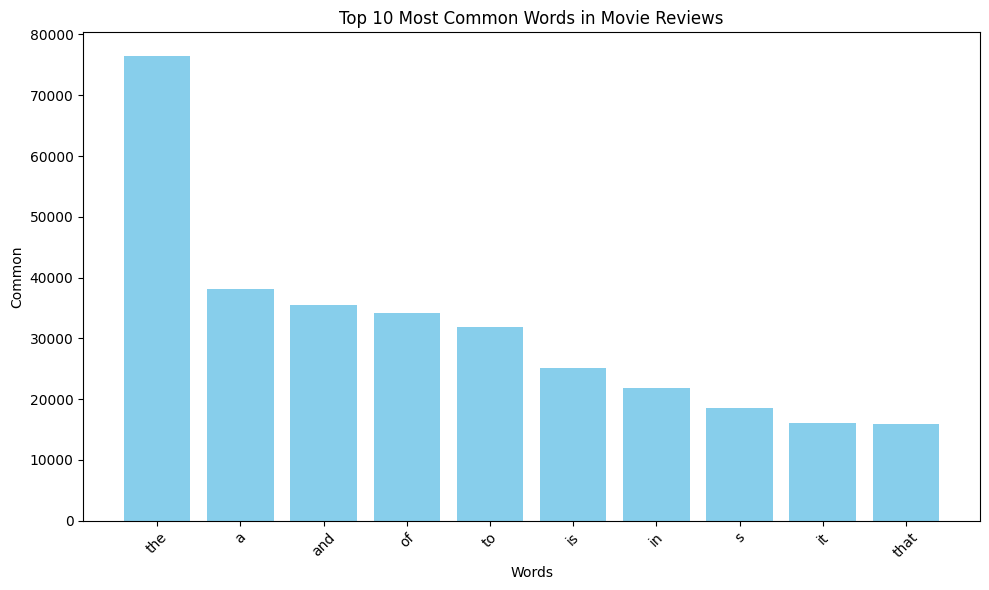

In [ ]:
from nltk import FreqDist
import matplotlib.pyplot as plt
# How often each word appears in the corpus
fdist = FreqDist(words_lower)
print(fdist.most_common(10))  # Top 10 most Common words

# Get top 10 most common words
top_words = fdist.most_common(10)

# Separate words and counts for plotting
words, counts = zip(*top_words)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.title("Top 10 Most Common Words in Movie Reviews")
plt.xlabel("Words")
plt.ylabel("Common")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Next, we took a look to find out the number of unique words that would represent half of the book. With a total of 1,329,753 words in the book we know that half of that is 664,876. In order to find out how many unique words makes up half of the book it conducts a loop and adds up the frequency of the unique words until it reaches 664,876. Results indicate 111 unique words represents 50% of the corpus.

In [ ]:
# Calculate halfway mark
total_words = len(words_lower)
half_total = total_words / 2

# Build cumulative list
cumulative = 0
unique_count = 0
words_used = []

for word, freq in fdist.most_common():
    cumulative += freq
    unique_count += 1
    words_used.append((word, freq, cumulative))
    if cumulative >= half_total:
        break

# Print summary
print(f"Total words: {total_words}")
print(f"Half of total: {half_total}")
print(f"Unique words covering 50% of corpus: {unique_count}")
print("\nWords contributing to 50% of corpus usage:\n")

# Print table
print("{:<5} {:<15} {:<10} {:<10}".format("No.", "Word", "Frequency", "Cumulative"))
print("-" * 45)

for i, (word, freq, cum) in enumerate(words_used[:10], start=1):
    print("{:<5} {:<15} {:<10} {:<10}".format(i, word, freq, cum))


Total words: 1329753
Half of total: 664876.5
Unique words covering 50% of corpus: 111

Words contributing to 50% of corpus usage:

No.   Word            Frequency  Cumulative
---------------------------------------------
1     the             76529      76529     
2     a               38106      114635    
3     and             35576      150211    
4     of              34123      184334    
5     to              31937      216271    
6     is              25195      241466    
7     in              21822      263288    
8     s               18513      281801    
9     it              16107      297908    
10    that            15924      313832    


We visualized the relationship between word rank and word frequency on a log–log scale to test Zipf’s Law.  
A roughly linear relationship on this plot indicates that the corpus follows Zipf’s distribution.


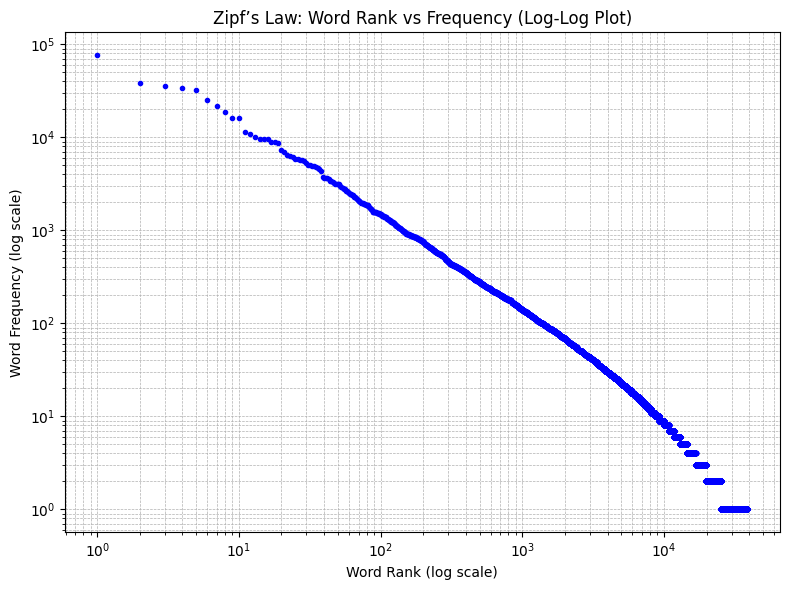

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get ranks and frequencies from the frequency distribution
ranks = np.arange(1, len(fdist) + 1)
frequencies = np.array([freq for word, freq in fdist.most_common()])

# Create the log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(ranks, frequencies, marker=".", linestyle='none', color='blue')
plt.title("Zipf’s Law: Word Rank vs Frequency (Log-Log Plot)")
plt.xlabel("Word Rank (log scale)")
plt.ylabel("Word Frequency (log scale)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

We looked at the top 200 most frequently used words in the corpus. With the words "the" and "a" being the highest used.

In [ ]:
# Get the 200 most frequent words
top_200 = fdist.most_common(200)

# Print Summary
print("Top 200 most frequent words in the movie_reviews corpus:\n")
print("{:<5} {:<15} {:<10}".format("No.", "Word", "Frequency"))
print("-" * 35)

for i, (word, freq) in enumerate(top_200, start=1):
    print("{:<5} {:<15} {:<10}".format(i, word, freq))

Top 200 most frequent words in the movie_reviews corpus:

No.   Word            Frequency 
-----------------------------------
1     the             76529     
2     a               38106     
3     and             35576     
4     of              34123     
5     to              31937     
6     is              25195     
7     in              21822     
8     s               18513     
9     it              16107     
10    that            15924     
11    as              11378     
12    with            10792     
13    for             9961      
14    his             9587      
15    this            9578      
16    film            9517      
17    i               8889      
18    he              8864      
19    but             8634      
20    on              7385      
21    are             6949      
22    t               6410      
23    by              6261      
24    be              6174      
25    one             5852      
26    movie           5771      
27    an       

We plotted the top 200 frequent words on a relative frequency. As you can see the word "the" accounts for 5.76% of all the words in the corpus.

Relative Frequency = Word Frequency / Total Words in Corpus

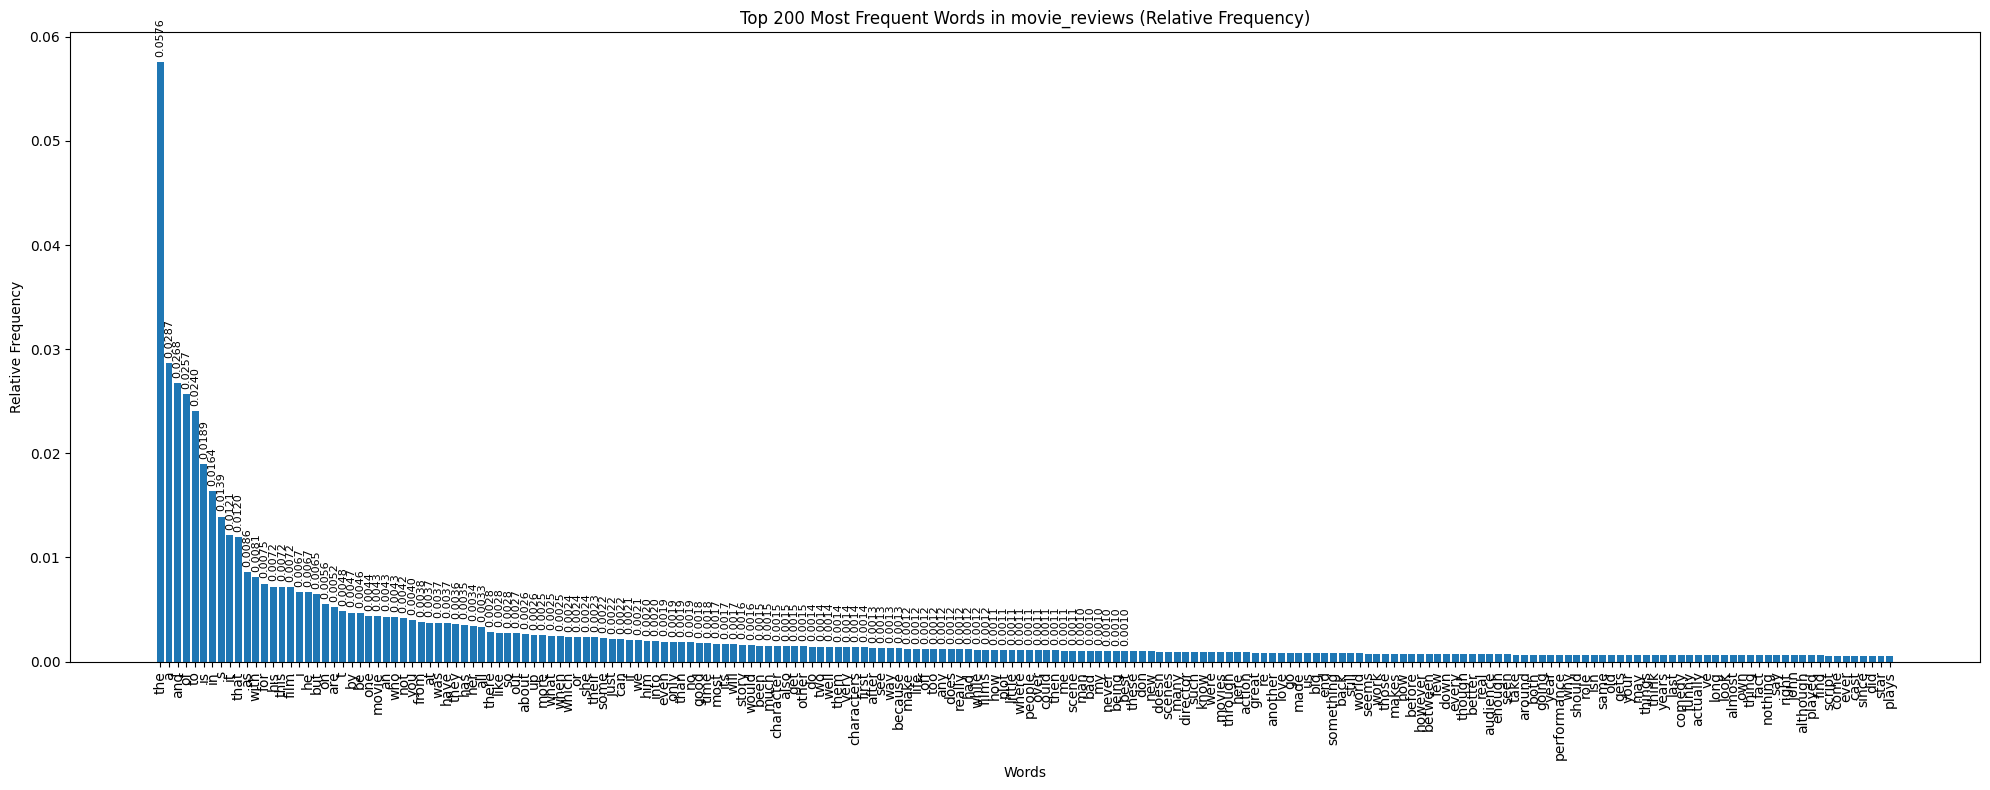

In [ ]:
# Calculate the relative frequency for the top 200 words
words = [word for word, freq in top_200]
relative_freqs = [freq / total_words for word, freq in top_200]

# Plot the relative frequency for top 200 words
plt.figure(figsize=(20, 8))
bars = plt.bar(range(200), relative_freqs, tick_label=words)
plt.xticks(rotation=90)
plt.title("Top 200 Most Frequent Words in movie_reviews (Relative Frequency)")
plt.xlabel("Words")
plt.ylabel("Relative Frequency")
plt.tight_layout()

# Add frequency labels above each bar (rounded to 4 decimal places)
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0.001:  # Only label bars that are tall enough to be visible
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.0005,
                 f"{relative_freqs[i]:.4f}",
                 ha='center', va='bottom', fontsize=8, rotation=90)

plt.show()

To check if the relative word frequencies follow Zipf’s law, we plotted the data on a log-log scale. If the plot forms a roughly straight line, it indicates that Zipf’s law holds true for the corpus. In the graph below, the line is relatively straight, which suggests that the corpus follows Zipf’s law.

Zipf’s law states that the most common word occurs about twice as often as the second most common word, three times as often as the third, and so on, resulting in a steeply declining frequency curve.



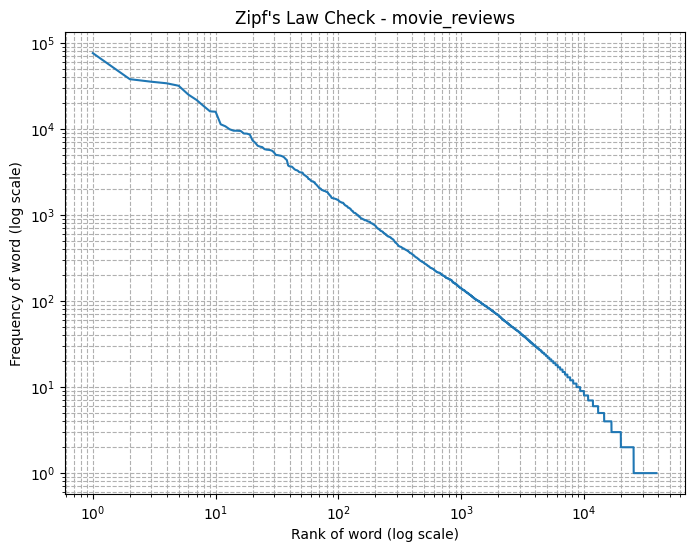

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

freqs = [freq for word, freq in fdist.most_common()]
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(8,6))
plt.loglog(ranks, freqs)
plt.title("Zipf's Law Check - movie_reviews")
plt.xlabel("Rank of word (log scale)")
plt.ylabel("Frequency of word (log scale)")
plt.grid(True, which="both", ls="--")
plt.show()


The word frequency in this corpus differs from that of general corpora because its content centers around expressing opinions about movies and whether customers like or dislike them. As a result, the vocabulary is mostly made up of opinion words and tends to be less complex compared to workplace writing, which often includes more formal language and industry-specific jargon used by companies.